In [148]:
from matplotlib.backends.backend_pdf import PdfPages
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

in_to_AU=1.914166336635137e-07/0.0000048481368118674
in_to_vel=1/1.58148106e-5

def xi_general(f, e_cm):
    f = np.asarray(f, dtype=float)
    e_cm = np.asarray(e_cm, dtype=float)

    xi = np.zeros_like(f, dtype=float)

    # (e < 1)
    mask_ell = e_cm < 1.0
    if np.any(mask_ell):
        num = np.sqrt(1.0 - e_cm[mask_ell]**2) * np.sin(f[mask_ell])
        den = e_cm[mask_ell] + np.cos(f[mask_ell])
        xi[mask_ell] = np.arctan2(num, den)

    # (e = 1)
    mask_par = np.isclose(e_cm, 1.0)
    if np.any(mask_par):
        xi[mask_par] = np.tan(f[mask_par] / 2.0)

    # C(e > 1)
    mask_hyp = e_cm > 1.0
    if np.any(mask_hyp):
        a = np.sqrt(e_cm[mask_hyp] + 1.0)
        b = np.sqrt(e_cm[mask_hyp] - 1.0)
        t = np.tan(f[mask_hyp] / 2.0)

        num = a + b * t
        den = a - b * t

        if np.any(num / den <= 0):
            raise ValueError("Log argument not postitive.")

        xi[mask_hyp] = np.log(num / den)

    return xi


def t_over_tau(f, e_cm, degrees=False):
    f = np.asarray(f, dtype=float)
    e_cm = np.asarray(e_cm, dtype=float)

    if degrees:
        f = np.deg2rad(f)

    xi = xi_general(f, e_cm)

    result = np.zeros_like(f, dtype=float)

    # elipse
    mask_ell = e_cm < 1.0
    if np.any(mask_ell):
        result[mask_ell] = (
            (1.0 - e_cm[mask_ell])**(-1.5)
            * (xi[mask_ell] - e_cm[mask_ell] * np.sin(xi[mask_ell]))
        )

    # parabolic
    mask_par = np.isclose(e_cm, 1.0)
    if np.any(mask_par):
        result[mask_par] = np.sqrt(2.0) * (
            xi[mask_par] + xi[mask_par]**3 / 3.0
        )

    # hyperbolic
    mask_hyp = e_cm > 1.0
    if np.any(mask_hyp):
        result[mask_hyp] = (
            (e_cm[mask_hyp] - 1.0)**(-1.5)
            * (e_cm[mask_hyp] * np.sinh(xi[mask_hyp]) - xi[mask_hyp])
        )

    return result

def true_anomaly(x, y, z, vx, vy, vz):

    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)

    # |r|
    r = np.sqrt(x*x + y*y + z*z)

    # v^2
    v2 = vx*vx + vy*vy + vz*vz

    # r · v
    rv = x*vx + y*vy + z*vz

    coef = v2 - 1.0/r

    # eccentricity vector
    ex = coef*x - rv*vx
    ey = coef*y - rv*vy
    ez = coef*z - rv*vz

    # |e|
    e = np.sqrt(ex*ex + ey*ey + ez*ez)

    # r · e
    re = x*ex + y*ey + z*ez

    # cos(f)
    cosf = re / (r * e)
    #cosf = np.clip(cosf, -1.0, 1.0)

    f = np.arccos(cosf)
    f = np.where(rv < 0, -f, f)         # [-π, π] continuos around 0
    
    return f

def data_bianca(Beta, e):
    path = "C:/Users/kelem/Downloads/file_leopoldo/file_leopoldo/beta"+str(Beta)+"_ec"+str(e)+"_2.csv"

    try:
        df1 = pd.read_csv(path)
    except Exception:
        df1 = pd.read_csv(path, sep=r"\s+|,", engine="python")
    
    cols = ["f", "x1", "y1", "z1", "x2", "y2", "z2", "xc", "yc", "ab", "eb", "ac", "ec", "a1", "a2", "e1", "e2", "vx1", "vy1", "vz1", "vx2", "vy2", "vz2"]
    missing = [c for c in cols if c not in df1.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el archivo: {missing}\nColumnas encontradas: {list(df.columns)}")
    
    for c in cols:
        df1[c] = pd.to_numeric(df1[c], errors="coerce")
    
    df1 = df1.dropna(subset=cols)

    zc=(df1["z1"]+df1["z2"])/2
    rc0 = np.sqrt(df1["xc"]**2 + df1["yc"]**2 )
    r10 = np.sqrt(df1["x1"]**2 + df1["y1"]**2 + df1["z1"]**2)
    r20 = np.sqrt(df1["x2"]**2 + df1["y2"]**2 + df1["z2"]**2)
    ab=df1["ab"]*0.1/Beta
    eb=df1["eb"]
    ac=df1["ac"]*0.1/Beta
    ec=df1["ec"]
    a1=df1["a1"]*0.1/Beta
    e1=df1["e1"]
    a2=df1["a2"]*0.1/Beta
    e2=df1["e2"]
    r10_2=np.array([df1["x1"], df1["y1"], df1["z1"]])
    r20_2=np.array([df1["x2"], df1["y2"], df1["z2"]])
    
    t_tau = t_over_tau(df1["f"], e)
    t_tau2 = t_tau - t_tau[0]

    return df1["f"], rc0, r10, r20, t_tau2, ab, eb, ac, ec, a1, e1, a2, e2, r10_2, r20_2, df1["x1"], df1["y1"], df1["z1"], df1["x2"], df1["y2"] , df1["z2"], df1["vx1"], df1["vy1"], df1["vz1"], df1["vx2"], df1["vy2"] , df1["vz2"], df1["xc"], df1["yc"], zc
    
def data_matteo(PN, Beta, e):
    path = "C:/Users/kelem/Desktop/Leopoldo/Maestria en astrofísica/Tesis/Small project/galcode/provePN"+str(PN)+"_"+str(Beta)+"_"+str(e)+"_phase_space_m2.dat" 

    df = pd.read_csv(path, sep=r"\s+", header=None, comment="#", engine="python")
    
    if df.shape[1] < 7:
        raise ValueError(f"El archivo tiene {df.shape[1]} columnas, pero necesito al menos 4 (t,x,y,z).")

    t = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    x1 = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    y1 = pd.to_numeric(df.iloc[:, 2], errors="coerce")
    z1 = pd.to_numeric(df.iloc[:, 3], errors="coerce")
    vx1 = pd.to_numeric(df.iloc[:, 4], errors="coerce")/(2.5e-6)
    vy1 = pd.to_numeric(df.iloc[:, 5], errors="coerce")/(2.5e-6)
    vz1 = pd.to_numeric(df.iloc[:, 6], errors="coerce")/(2.5e-6)
    
    mask = t.notna() & x1.notna() & y1.notna() & z1.notna() & vx1.notna() & vy1.notna() & vz1.notna()
    t, x1, y1, z1, vx1, vy1, vz1 = t[mask], x1[mask], y1[mask], z1[mask], vx1[mask], vy1[mask], vz1[mask]
    
    r1 = np.sqrt((x1)**2 + (y1)**2 + (z1)**2)
    r1_2 = np.array([x1, y1, z1])
    v1 = np.array([vx1, vy1, vz1])

    path = "C:/Users/kelem/Desktop/Leopoldo/Maestria en astrofísica/Tesis/Small project/galcode/provePN"+str(PN)+"_"+str(Beta)+"_"+str(e)+"_phase_space_m3.dat"  

    df = pd.read_csv(path, sep=r"\s+", header=None, comment="#", engine="python")
    
    if df.shape[1] < 7:
        raise ValueError(f"El archivo tiene {df.shape[1]} columnas, pero necesito al menos 4 (t,x,y,z).")
    
    t = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    x2 = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    y2 = pd.to_numeric(df.iloc[:, 2], errors="coerce")
    z2 = pd.to_numeric(df.iloc[:, 3], errors="coerce")
    vx2 = pd.to_numeric(df.iloc[:, 4], errors="coerce")/2.5e-6
    vy2 = pd.to_numeric(df.iloc[:, 5], errors="coerce")/2.5e-6
    vz2 = pd.to_numeric(df.iloc[:, 6], errors="coerce")/2.5e-6
    
    mask = t.notna() & x2.notna() & y2.notna() & z2.notna() & vx2.notna() & vy2.notna() & vz2.notna()
    t, x2, y2, z2, vx2, vy2, vz2 = t[mask], x2[mask], y2[mask], z2[mask], vx2[mask], vy2[mask], vz2[mask]
    
    r2 = np.sqrt(x2**2 + y2**2 + z2**2)
    r2_2 = np.array([x2, y2, z2])
    v2 = np.array([vx2, vy2, vz2])

    xc = (x1+x2)/2
    yc = (y1+y2)/2
    zc = (z1+z2)/2
    vxc = (vx1+vx2)/2
    vyc = (vy1+vy2)/2
    vzc = (vz1+vz2)/2

    rc_2 = np.array([xc, yc, zc])
    vc_2 = np.array([vxc, vyc, vzc])
    
    vc = (vxc**2 + vyc**2 + vzc**2)**(1/2)
    
    rc = (xc**2 + yc**2)**(1/2)

    f = true_anomaly(xc, yc, zc, vxc, vyc, vzc)

    return r1, r2, rc, xc, yc, zc, t, vxc, vyc, vzc, f, v1, v2, r1_2, r2_2, rc_2, vc_2, x1, x2, y1, y2, z1, z2, vx1, vx2, vy1, vy2, vz1, vz2

def comparison3_in_tf(PN, t_tau3, r10, r20, rc0, t, rc, r1, r2, f, f_b):
    from matplotlib.backends.backend_pdf import PdfPages
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10),sharex=True)
    
    ax1.plot(t_tau3, ((r10_2-r20_2)[0,:]**2+(r10_2-r20_2)[1,:]**2+(r10_2-r20_2)[2,:]**2)**(1/2), label="Bianca", linestyle='--')
    ax1.plot(t*6.243175587042446e-07, (((r1_2-r2_2)[0,:]**2+(r1_2-r2_2)[1,:]**2+(r1_2-r2_2)[2,:]**2)**(1/2)*in_to_AU), label="GALCODE", linewidth=0.8)
    ax1.set_ylabel("r [AU]")
    ax1.set_xlabel("t [yr]")
    ax1.set_yscale('symlog', linthresh=1e-2)
    ax1.set_title("Relative separation of tha binary's element")
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(t_tau3, rc0, label="Bianca", linestyle='--')
    ax2.plot(t*6.243175587042446e-07, rc*in_to_AU, label="GALCODE", linewidth=0.8)
    ax2.set_ylabel("r [AU]")
    ax2.set_xlabel("t [yr]")
    ax2.set_yscale('symlog', linthresh=1e-2)
    ax2.set_title("r_COM")
    ax2.legend()
    ax2.grid(True)
    
    fig.tight_layout()
    
    with PdfPages("PN"+str(PN)+" time domain comparison new.pdf") as pdf:
        pdf.savefig(fig)
    plt.close(fig)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10),sharex=True)
    
    ax1.plot(f_b, ((r10_2-r20_2)[0,:]**2+(r10_2-r20_2)[1,:]**2+(r10_2-r20_2)[2,:]**2)**(1/2), label="Bianca", linestyle='--')
    ax1.plot(f, (((r1_2-r2_2)[0,:]**2+(r1_2-r2_2)[1,:]**2+(r1_2-r2_2)[2,:]**2)**(1/2)*in_to_AU), label="GALCODE", linewidth=0.8)
    ax1.set_ylabel("r [AU]")
    ax1.set_xlabel("f")
    ax1.set_yscale('symlog', linthresh=1e-2)
    ax1.set_title("Relative separation of tha binary's element")
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(f_b, rc0, label="Bianca", linestyle='--')
    ax2.plot(f, rc*in_to_AU, label="GALCODE", linewidth=0.8)
    ax2.set_ylabel("r [AU]")
    ax2.set_xlabel("f")
    ax2.set_yscale('symlog', linthresh=1e-2)
    ax2.set_title("r_COM")
    ax2.legend()
    ax2.grid(True)
    
    fig.tight_layout()
    
    with PdfPages("PN"+str(PN)+" f domain comparison new.pdf") as pdf:
        pdf.savefig(fig)
    
    plt.close(fig)

#propiedades orbitales

import astropy
import astropy.units as u
G_default=astropy.constants.G.to(u.Msun**-1 * u.AU**3 * u.yr**-2).value

def E_L(q, r, v, m=1, G=G_default):
    m1=m/(1+q)
    m2=q*m/(1+q)
    if len(r.shape)==1:
        r,v=r[:,None],v[:,None]
    mu = m1*m2/(m1+m2)
    E = np.squeeze(0.5*mu*np.linalg.norm(v,axis=0)**2-G*m1*m2/np.linalg.norm(r,axis=0))
    L = mu*np.cross(r,v,axis=0)
    
    return E, np.squeeze(L[0,:]), np.squeeze(L[1,:]), np.squeeze(L[2,:])

def state_to_elements(q, r, v, m=1, G=G_default):
    if len(r.shape)==1:
        r,v=r[:,None],v[:,None]
    m1=m/(1+q)
    m2=q*m/(1+q)
    mu=m1*m2/(m1+m2)
    rs=np.linalg.norm(r,axis=0)
    vs=np.linalg.norm(v,axis=0)
    
    vrs=np.sum(r*v,axis=0)/rs
    
    E, Lx, Ly, Lz = E_L(q, r, v, m=m,G=G)
    a=-G*m1*m2/(2*E)
    
    e=np.sqrt(1+(2*E*(Lx**2+Ly**2+Lz**2))/((G**2)*(m1**2)*(m2**2)*mu))
    c_phi=(a*(1-e**2)/(e*rs)-1/e)
    
    s_phi=1/e*(np.sqrt(1+2*e*c_phi+e**2))*vrs/vs
    phi=np.arctan2(s_phi,c_phi)

    rx=r[0,:]/rs
    ry=r[1,:]/rs
    rz=r[2,:]/rs

    z1=Lx/np.sqrt(Lx**2+Ly**2+Lz**2)
    z2=Ly/np.sqrt(Lx**2+Ly**2+Lz**2)
    z3=Lz/np.sqrt(Lx**2+Ly**2+Lz**2)

    x1=rx*np.cos(phi)+(ry*z3-z2*rz)*np.sin(phi)
    x2=ry*np.cos(phi)+(rz*z1-z3*rx)*np.sin(phi)
    x3=rz*np.cos(phi)+(rx*z2-z1*ry)*np.sin(phi)

    y1=z2*x3-z3*x2
    y2=z3*x1-z1*x3
    y3=z1*x2-z2*x1

    i=np.arctan2(np.sqrt(z1**2+z2**2),z3)
    om=np.arctan2(x3,y3)
    Om=np.arctan2(z1,-z2)

    return np.squeeze(np.vstack([a, e, phi, Om, i, om]))

def comparison_orbital_propiertes(a10, e10, a20, e20, a1, e1, a2, e2, t, t0, f, f_b):

    fig_a, axes_a = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    ax = axes_a[0]
    ax.plot(t0, a10, label='a1 (Bianca)', linestyle='--')
    ax.plot(t, a1, label='a1 (Galcode)', linewidth=0.8)
    ax.set_ylabel("Semi-major axis (AU)")
    ax.set_yscale('symlog', linthresh=1e6)
    ax.set_xlabel("time [yr]")
    ax.set_title("Beta "+str(Beta)+" e "+str(e)+" case")
    ax.legend()
    ax.grid(True)

    ax = axes_a[1]
    ax.plot(t0, a20, label='a2 (Bianca)', linestyle='--')
    ax.plot(t, a2, label='a2 (Galcode)', linewidth=0.8)
    ax.set_ylabel("Semi-major axis (AU)")
    ax.set_yscale('symlog', linthresh=1e6)
    ax.set_xlabel("time [yr]")
    ax.legend()
    ax.grid(True)
    fig_a.tight_layout()
    #fig_a.savefig("a_comparison PN "+str(PN)+".pdf")
    plt.close(fig_a)

    fig_e, axes_e = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    ax = axes_e[0]
    ax.plot(t0, e10, label='e1 (Bianca)', linestyle='--')
    ax.plot(t, e1, label='e1 (Galcode)', linewidth=0.8)
    ax.set_yscale('symlog', linthresh=1e-2)
    ax.set_ylabel("Eccentricity")
    ax.set_xlabel("Time [yr]")
    ax.set_title("Beta "+str(Beta)+" e "+str(e)+" case")
    ax.legend()
    ax.grid(True)

    ax = axes_e[1]
    ax.plot(t0, e20, label='e2 (Bianca)', linestyle='--')    
    ax.plot(t, e2, label='e2 (Galcode)', linewidth=0.8)
    ax.set_yscale('symlog', linthresh=1e-2)
    ax.set_ylabel("Eccentricity")
    ax.set_xlabel("Time [yr]")
    ax.legend()
    ax.grid(True)

    fig_e.tight_layout()
    fig_e.savefig("e_comparison_2bodies_t PN "+str(PN)+".pdf")
    plt.close(fig_e)

    fig_e, axes_e = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    ax = axes_e[0]
    ax.plot(f_b, e10, label='e1 (Bianca)', linestyle='--')
    ax.plot(f, e1, label='e1 (Galcode)', linewidth=0.8)
    ax.set_yscale('symlog', linthresh=1e-2)
    ax.set_ylabel("Eccentricity")
    ax.set_xlabel("f")
    ax.set_title("Beta "+str(Beta)+" e "+str(e)+" case")
    ax.legend()
    ax.grid(True)

    ax = axes_e[1]
    ax.plot(f_b, e20, label='e2 (Bianca)', linestyle='--')    
    ax.plot(f, e2, label='e2 (Galcode)', linewidth=0.8)
    ax.set_yscale('symlog', linthresh=1e-2)
    ax.set_ylabel("Eccentricity")
    ax.set_xlabel("f")
    ax.legend()
    ax.grid(True)

    fig_e.tight_layout()
    fig_e.savefig("e_comparison_2bodies__f PN "+str(PN)+".pdf")
    plt.close(fig_e)

def comparison_orbital_binary(ab0, eb0, ac0, ec0, ab, eb, ac, ec, t, t0, f, f_b):

    fig_a, axes_a = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    ax = axes_a[0]
    ax.plot(t0, ab0, label='ab (Bianca)', linestyle='--')
    ax.plot(t, ab, label='ab (Galcode)', linewidth=0.8)
    ax.set_ylabel("Semi-major axis (AU)")
    ax.set_yscale('symlog', linthresh=1e6)
    ax.set_xlabel("time [yr]")
    ax.set_title("Beta "+str(Beta)+" e "+str(e)+" case")
    ax.legend()
    ax.grid(True)

    ax = axes_a[1]
    ax.plot(t0, ac0, label='ac (Bianca)', linestyle='--')
    ax.plot(t, ac, label='ac (Galcode)', linewidth=0.8)
    ax.set_ylabel("Semi-major axis (AU)")
    ax.set_yscale('symlog', linthresh=1e6)
    ax.set_xlabel("time [yr]")
    ax.legend()
    ax.grid(True)

    fig_a.tight_layout()
    #fig_a.savefig("a_comparison_binary PN "+str(PN)+".pdf")
    plt.close(fig_a)

    fig_e, axes_e = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    ax = axes_e[0]
    ax.plot(t0, eb0, label='eb (Bianca)', linestyle='--')
    ax.plot(t, eb, label='eb (Galcode)', linewidth=0.8)
    ax.set_yscale('symlog', linthresh=1e-2)
    ax.set_ylabel("Eccentricity")
    ax.set_xlabel("Time [yr]")
    ax.set_title("Beta "+str(Beta)+" e "+str(e)+" case")
    ax.legend()
    ax.grid(True)

    ax = axes_e[1]
    ax.plot(t0, ec0, label='ec (Bianca)', linestyle='--')    
    ax.plot(t, ec, label='ec (Galcode)', linewidth=0.8)
    #ax.set_yscale('symlog', linthresh=1e-2)
    ax.set_ylabel("Eccentricity")
    ax.set_xlabel("Time [yr]")
    ax.legend()
    ax.grid(True)
    fig_e.tight_layout()
    fig_e.savefig("e_comparison_binary_t PN "+str(PN)+".pdf")
    plt.close(fig_e)

    fig_e, axes_e = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    ax = axes_e[0]
    ax.plot(f_b, eb0, label='eb (Bianca)', linestyle='--')
    ax.plot(f, eb, label='eb (Galcode)', linewidth=0.8)
    ax.set_yscale('symlog', linthresh=1e-2)
    ax.set_ylabel("Eccentricity")
    ax.set_xlabel("f")
    ax.set_title("Beta "+str(Beta)+" e "+str(e)+" case")
    ax.legend()
    ax.grid(True)

    ax = axes_e[1]
    ax.plot(f_b, ec0, label='ec (Bianca)', linestyle='--')    
    ax.plot(f, ec, label='ec (Galcode)', linewidth=0.8)
    #ax.set_yscale('symlog', linthresh=1e-2)
    ax.set_ylabel("Eccentricity")
    ax.set_xlabel("f")
    ax.legend()
    ax.grid(True)
    fig_e.tight_layout()
    fig_e.savefig("e_comparison_binary_f PN "+str(PN)+".pdf")
    plt.close(fig_e)

# chek intial condition

def Compared_init(x10, x20, y10, y20, z10, z20,
                  x1, x2, y1, y2, z1, z2,
                  t, t_b, s):

    indice1 = np.argmin(np.abs(t - s))
    indice2 = np.argmin(np.abs(t_b - s))

    fig_a = plt.figure(figsize=(8, 10))

    ax1 = fig_a.add_subplot(2, 1, 1, projection='3d')
    ax1.plot(x10[:indice2], y10[:indice2], z10[:indice2], label='1st body Bianca', linestyle='--')
    ax1.plot(x1[:indice1], y1[:indice1], z1[:indice1], label='1st body GALCODE', linewidth=0.8)
    ax1.scatter(x10[0], y10[0], z10[0], s=10, marker='o')
    ax1.scatter(x1[0],  y1[0],  z1[0],  s=10, marker='x')
    ax1.set_xlabel('X[AU]')
    ax1.set_ylabel('Y[AU]')
    ax1.set_zlabel('Z[AU]')
    ax1.set_title("Bodies trayectories during the first "+str(s)+" yr")
    ax1.legend()
    ax1.grid(True)

    ax2 = fig_a.add_subplot(2, 1, 2, projection='3d')
    ax2.plot(x20[:indice2], y20[:indice2], z20[:indice2], label='2nd body Bianca', linestyle='--')
    ax2.plot(x2[:indice1], y2[:indice1], z2[:indice1], label='2nd body GALCODE', linewidth=0.8)
    ax2.scatter(x20[0], y20[0], z20[0], s=10, marker='o')
    ax2.scatter(x2[0],  y2[0],  z2[0],  s=10, marker='x')
    ax2.set_xlabel('X[AU]')
    ax2.set_ylabel('Y[AU]')
    ax2.set_zlabel('Z[AU]')
    ax2.legend()
    ax2.grid(True)

    fig_a.tight_layout()
    fig_a.savefig("Bodies_initial_trayectory.pdf")
    plt.close(fig_a)

def Compared_init_vel(vx10, vx20, vy10, vy20, vz10, vz20,
                  vx1, vx2, vy1, vy2, vz1, vz2,
                  t, t_b, s):

    indice1 = np.argmin(np.abs(t - s))
    indice2 = np.argmin(np.abs(t_b - s))

    fig_a = plt.figure(figsize=(8, 10))

    ax1 = fig_a.add_subplot(2, 1, 1, projection='3d')
    ax1.plot(vx10[:indice2], vy10[:indice2], vz10[:indice2], label='1st body Bianca', linestyle='--')
    ax1.plot(vx1[:indice1], vy1[:indice1], vz1[:indice1], label='1st body GALCODE', linewidth=0.8)
    ax1.scatter(vx10[0], vy10[0], vz10[0], s=10, marker='o')
    ax1.scatter(vx1[0],  vy1[0],  vz1[0],  s=10, marker='x')
    ax1.set_xlabel('vx[AU/yr]')
    ax1.set_ylabel('vy[AU/yr]')
    ax1.set_zlabel('vz[AU/yr]')
    ax1.set_title("Bodies velocities during the first "+str(s)+" yr")
    ax1.legend()
    ax1.grid(True)

    ax2 = fig_a.add_subplot(2, 1, 2, projection='3d')
    ax2.plot(vx20[:indice2], vy20[:indice2], vz20[:indice2], label='2nd body Bianca', linestyle='--')
    ax2.plot(vx2[:indice1], vy2[:indice1], vz2[:indice1], label='2nd body GALCODE', linewidth=0.8)
    ax2.scatter(vx20[0], vy20[0], vz20[0], s=10, marker='o')
    ax2.scatter(vx2[0],  vy2[0],  vz2[0],  s=10, marker='x')
    ax2.set_xlabel('vx[AU/yr]')
    ax2.set_ylabel('vy[AU/yr]')
    ax2.set_zlabel('vz[AU/yr]')
    ax2.legend()
    ax2.grid(True)

    fig_a.tight_layout()
    fig_a.savefig("Bodies_initial_velocities.pdf")
    plt.close(fig_a)

def CM_trayectory(xc0, yc0, zc0, xc, yc, zc):
    fig_a = plt.figure(figsize=(8, 10))

    ax1 = fig_a.add_subplot(1, 1, 1)
    ax1.plot(xc0, yc0, label='CMs trayectory Bianca', linestyle='--')
    ax1.plot(xc, yc, label='CMs trayectory Galcode', linewidth=0.8)
    ax1.scatter(0, 0, s=10, marker='o', color='r', label='MBH')
    ax1.set_xlabel('x[AU]')
    ax1.set_ylabel('y[AU]')
    ax1.set_xlim(-2,2)
    ax1.set_ylim(-2,2)
    ax1.set_title("CMs trayectory comparison")
    ax1.legend()
    ax1.grid(True)
    fig_a.tight_layout()
    fig_a.savefig("CMs trayectory.pdf")
    plt.close(fig_a)

In [182]:
# lets go
PN=0
Beta=1
e=1.99999

df1, rc0, r10, r20, t_tau_2, ab0, eb0, ac0, ec0, a10, e10, a20, e20, r10_2, r20_2, x10, y10, z10, x20, y20, z20, vx10, vy10, vz10, vx20, vy20, vz20, xc0, yc0, zc0 = data_bianca(Beta,e)
r1, r2, rc, xc, yc, zc, t, vxc, vyc, vzc, f, v1, v2, r1_2, r2_2, rc_2, vc_2, x1, x2, y1, y2, z1, z2, vx1, vx2, vy1, vy2, vz1, vz2 = data_matteo(PN, Beta, e)

G = 6.67430e-11                
M_sun = 1.9885e30              
AU = 1.495978707e11            
yr = 3.15576e7                 

a_b = 0.1 * AU                 
M = 20 * M_sun                 

tau_seconds = (Beta**(-1.5)) * np.sqrt(a_b**3 / (G * M))
k = tau_seconds / yr
t_tau_3 = t_tau_2*k

#cuerpo 1 con respecto al MBH
m0=4e6
m1=10
m2=10

m_tot1=m0+m1 #en solares
q1=m0/m1

m_tot2=m0+m2 #en solares
q2=m0/m2

m_tot3=m1+m2 #en solares
q3=m1/m2

m_tot4=m0+m_tot3 #en solares
q4=m0/m_tot3



a1, e1, phi1, Om1, i1, om1 = state_to_elements(q1, (r1_2*in_to_AU), (v1*in_to_vel), m=m_tot1, G=G_default)
a2, e2, phi2, Om2, i2, om2 = state_to_elements(q2, (r2_2*in_to_AU), (v2*in_to_vel), m=m_tot2, G=G_default)
ab, eb, phib, Omb, ib, omb = state_to_elements(q3, (r2_2-r1_2)*in_to_AU, (v2-v1)*in_to_vel, m=m_tot3, G=G_default)
ac, ec, phic, Omc, ic, omc = state_to_elements(q4, (rc_2*in_to_AU), (vc_2*in_to_vel), m=m_tot4, G=G_default)

comparison3_in_tf(PN, t_tau_3, r10_2, r20_2, rc0, t, rc, r1_2, r2_2, f, df1)
comparison_orbital_propiertes(a10, e10, a20, e20, a1, e1, a2, e2, t*6.243175587042446e-07, t_tau_3, f, df1)
comparison_orbital_binary(ab0, eb0, ac0, ec0, ab, eb, ac, ec, t*6.243175587042446e-07, t_tau_3, f, df1)
s=0.01
CM_trayectory(xc0, yc0, zc0, xc*in_to_AU, yc*in_to_AU, zc*in_to_AU)
Compared_init_vel(vx10, vx20, vy10, vy20, vz10, vz20, vx1*in_to_vel, vx2*in_to_vel, vy1*in_to_vel, vy2*in_to_vel, vz1*in_to_vel, vz2*in_to_vel, t*6.243175587042446e-07, t_tau_3, s)
Compared_init(x10, x20, y10, y20, z10, z20, x1*in_to_AU, x2*in_to_AU, y1*in_to_AU, y2*in_to_AU, z1*in_to_AU, z2*in_to_AU, t*6.243175587042446e-07, t_tau_3, s)

In [184]:
#Initial conditions

v=np.array([514.696610336642,	11.5759702117846,	27.8341244620836,	582.3170812218,	-3.38742715532177,	-27.8341244620836])
ve=v/(in_to_vel/2.5e-6)
ve

r=np.array([-1049.55095177494,	-15.6328226556548,	-0.0300330369278775,	-1049.51757951922,	-15.7054749737147,	0.0300330369278775])
re=r/in_to_AU
re

array([-2.65826773e+04, -3.95942931e+02, -7.60666767e-01, -2.65818321e+04,
       -3.97783045e+02,  7.60666767e-01])

In [ ]:
#Some less important analysis

def analizar_oscilaciones(tiempo, datos):
    
    peaks, _ = find_peaks(datos, prominence=1e-6)

    tiempos_oscilacion = tiempo[peaks]

    numero_oscilacion = np.arange(1, len(peaks))

    contador = np.zeros_like(tiempo)
    conteo = 0

    for i in range(1, len(peaks)):
        idx = peaks[i]
        conteo += 1
        contador[idx:] = conteo

    periodos = []
    amplitudes = []
    medias = []
    tiempos_oscilacion = []

    for i in range(len(peaks) - 1):
        idx_inicio = peaks[i]
        idx_fin = peaks[i + 1]

        t_segmento = tiempo[idx_inicio:idx_fin]
        d_segmento = datos[idx_inicio:idx_fin]

        periodo = tiempo[idx_fin] - tiempo[idx_inicio]
        amplitud = (np.max(d_segmento) - np.min(d_segmento)) / 2
        media = np.mean(d_segmento)

        periodos.append(periodo)
        amplitudes.append(amplitud)
        medias.append(media)
        tiempos_oscilacion.append(np.mean(t_segmento))

    return (contador,
            np.array(periodos),
            np.array(amplitudes),
            np.array(medias),
            np.array(tiempos_oscilacion), tiempos_oscilacion, numero_oscilacion)
    
#0 es bianca, sin 0 es matteo
def comparison1_in_t(PN, t_tau3, r10, r20, rc0, t, rc, r1, r2):
    from matplotlib.backends.backend_pdf import PdfPages
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10),sharex=True)
    
    ax1.plot(t_tau3, r10-rc0, label="r1c")
    ax1.plot(t_tau3, r20-rc0, label="r2c")
    ax1.set_ylabel("r [AU]")
    ax1.set_xlabel("t [yr]")
    ax1.set_yscale('symlog', linthresh=1e-2)
    ax1.set_title("Bianca's code")
    ax1.grid(True)
    
    ax2.plot(t*6.243175587042446e-07, (r1-rc)*in_to_AU, label="r1c")
    ax2.plot(t*6.243175587042446e-07, (r2-rc)*in_to_AU, label="r2c")
    ax2.set_ylabel("r [AU]")
    ax2.set_xlabel("t [yr]")
    ax2.set_yscale('symlog', linthresh=1e-2)
    ax2.set_title("Galcode "+str(PN)+"PN correction")
    ax2.grid(True)
    
    fig.tight_layout()
    
    with PdfPages("PN"+str(PN)+" time domain comparison.pdf") as pdf:
        pdf.savefig(fig)
    
    plt.close(fig)

def comparison2_in_t(PN, corpo, periodos1, periodos2,
                     amplitudes1, amplitudes2,
                     t1, n1, t2, n2):

    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(3, 1, figsize=(8, 12))

    axes[0].scatter(range(1, len(periodos1)+1), periodos1, s=5, label="Galcode")
    axes[0].scatter(range(1, len(periodos2)+1), periodos2, s=5, label="Bianca")
    axes[0].set_title("Period vs # of cycle")
    axes[0].set_ylabel("Period [yr]")
    axes[0].legend()

    axes[1].scatter(range(1, len(amplitudes1)+1), amplitudes1, s=5, label="Galcode")
    axes[1].scatter(range(1, len(amplitudes2)+1), amplitudes2, s=5, label="Bianca")
    axes[1].set_title("Amplitude vs # of cycle")
    axes[1].set_ylabel("Amplitude [AU]")
    axes[1].legend()
    
    axes[2].scatter(t1, n1, s=5, label="Galcode")
    axes[2].scatter(t2, n2, s=5, label="Bianca")
    axes[2].set_title("# of cycle vs time")
    axes[2].set_xlabel("Time [yr]")
    axes[2].set_ylabel("# Cycle")
    axes[2].legend()

    fig.tight_layout()

    # Guardar PDF
    with PdfPages("comparison_cycles_t_domain "+str(PN)+"PN for body #"+str(corpo)+".pdf") as pdf:
        pdf.savefig(fig)

    plt.close(fig)

def comparison1_in_f(PN, f_b, r10, r20, rc0, f, rc, r1, r2):
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10),sharex=True)
    
    ax1.plot(f_b, r10-rc0, label="r1c")
    ax1.plot(f_b, r20-rc0, label="r2c")
    ax1.set_ylabel("r [AU]")
    ax1.set_xlabel("f")
    ax1.set_yscale('symlog', linthresh=1e-2)
    ax1.set_title("Bianca's code")
    ax1.grid(True)
    
    ax2.plot(f, (r1-rc)*in_to_AU, label="r1c")
    ax2.plot(f, (r2-rc)*in_to_AU, label="r2c")
    ax2.set_ylabel("r [AU]")
    ax2.set_xlabel("f")
    ax2.set_yscale('symlog', linthresh=1e-2)
    ax2.set_title("Galcode "+str(PN)+"PN correction")
    ax2.grid(True)
    
    fig.tight_layout()
    
    with PdfPages("PN"+str(PN)+" f domain comparison.pdf") as pdf:
        pdf.savefig(fig)
    
    plt.close(fig)

def comparison2_in_f(PN, corpo, periodos1, periodos2,
                     amplitudes1, amplitudes2,
                     t1, n1, t2, n2):

    fig, axes = plt.subplots(3, 1, figsize=(8, 12))

    axes[0].scatter(range(1, len(periodos1)+1), periodos1, s=5, label="Galcode")
    axes[0].scatter(range(1, len(periodos2)+1), periodos2, s=5, label="Bianca")
    axes[0].set_title("Period in f vs # of cycle")
    axes[0].set_ylabel("Period [f]")
    axes[0].legend()

    axes[1].scatter(range(1, len(amplitudes1)+1), amplitudes1, s=5, label="Galcode")
    axes[1].scatter(range(1, len(amplitudes2)+1), amplitudes2, s=5, label="Bianca")
    axes[1].set_title("Amplitude vs # of cycle")
    axes[1].set_ylabel("Amplitude [AU]")
    axes[1].legend()
    
    axes[2].scatter(t1, n1, s=5, label="Galcode")
    axes[2].scatter(t2, n2, s=5, label="Bianca")
    axes[2].set_title("# of cycle vs f")
    axes[2].set_xlabel("f")
    axes[2].set_ylabel("# Cycle")
    axes[2].legend()

    fig.tight_layout()

    # Guardar PDF
    with PdfPages("comparison_cycles_f_domain "+str(PN)+"PN for body #"+str(corpo)+".pdf") as pdf:
        pdf.savefig(fig)

    plt.close(fig)

In [87]:

contador1, periodos1, amplitudes1, medias1, t_osc1, t1, n1 = analizar_oscilaciones(t*6.243175587042446e-07, (r1-rc)*0.039) #cuerpo uno
contador2, periodos2, amplitudes2, medias2, t_osc2, t2, n2 = analizar_oscilaciones(t_tau_3, (r10-rc0))

comparison2_in_t(PN, 1, periodos1, periodos2,amplitudes1, amplitudes2,t1, n1, t2, n2)


contador1, periodos1, amplitudes1, medias1, t_osc1, t1, n1 = analizar_oscilaciones(t*6.243175587042446e-07, (r2-rc)*0.039) #cuerpo uno
contador2, periodos2, amplitudes2, medias2, t_osc2, t2, n2 = analizar_oscilaciones(t_tau_3, (r20-rc0))

comparison2_in_t(PN, 2, periodos1, periodos2,amplitudes1, amplitudes2,t1, n1, t2, n2)

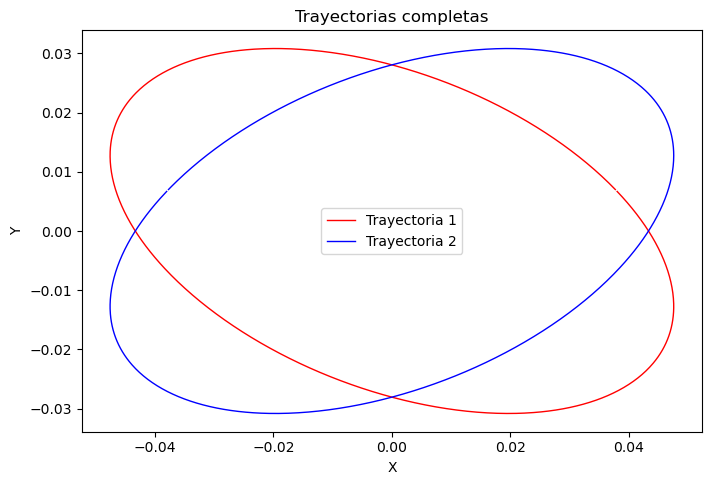

In [575]:
#trayectory 
from matplotlib.animation import FuncAnimation, PillowWriter

x1= (df1["x1"] - df1["xc"])[:1000]
y1= (df1["y1"] - df1["yc"])[:1000]
x2= (df1["x2"] - df1["xc"])[:1000]
y2= (df1["y1"] - df1["yc"])[:1000]
t=t_tau2

fig, ax = plt.subplots(figsize=(8,8))

ax.plot(x1, y1, lw=1, color='red', label='Trayectoria 1')
ax.plot(x2, y2, lw=1, color='blue', label='Trayectoria 2')

#ax.scatter(x1[0], y1[0], color='darkred', s=30, label='Inicio 1')
#ax.scatter(x1.iloc[-1], y1.iloc[-1], color='pink', s=30, label='Fin 1')

#ax.scatter(x2[0], y2[0], color='darkblue', s=30, label='Inicio 2')
#ax.scatter(x2.iloc[-1], y2.iloc[-1], color='lightblue', s=30, label='Fin 2')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Complete Trayectories')
ax.legend()
ax.set_aspect('equal') 

plt.show()